In [1]:
# Phase 4 – Temporal Network Construction
# Cell 1: Setup + Load Clean Data

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import networkx as nx

# ---------------------- Paths ----------------------
PROJECT = Path(r"D:\univercity\omid_project\economics_project")

PHASE2_DATA = PROJECT / "outputs" / "phase2" / "data"
OUT_DIR     = PROJECT / "outputs" / "phase4"

OUT_DATA  = OUT_DIR / "data"
OUT_TAB   = OUT_DIR / "tables"
OUT_FIG   = OUT_DIR / "figures"
OUT_LOG   = OUT_DIR / "logs"

for d in [OUT_DATA, OUT_TAB, OUT_FIG, OUT_LOG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 4 – Temporal Network Construction | Cell 1")
print("=" * 60)
print(f"Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Project Root  : {PROJECT}")
print(f"Outputs       : {OUT_DIR}")
print()

# Load final clean panel
df = pd.read_pickle(PHASE2_DATA / "jst_final_clean.pkl")

print("Loaded data:")
print(f"  Shape      : {df.shape}")
print(f"  Countries  : {df['country'].nunique()}")
print(f"  Years      : {df['year'].min()} – {df['year'].max()}")
print("\nCell 1 completed successfully.")

Phase 4 – Temporal Network Construction | Cell 1
Timestamp     : 2026-09-23 10:41:14
Project Root  : D:\univercity\omid_project\economics_project
Outputs       : D:\univercity\omid_project\economics_project\outputs\phase4

Loaded data:
  Shape      : (2718, 60)
  Countries  : 18
  Years      : 1870 – 2020

Cell 1 completed successfully.


In [2]:
# Phase 4 – Temporal Network Construction
# Cell 2: Define Nodes + Build Proxy Networks (per country-year)

import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase4" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase4" / "tables"

df = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "jst_final_clean.pkl")

print("=" * 60)
print("Phase 4 – Temporal Network Construction | Cell 2")
print("Building Proxy Sectoral Networks")
print("=" * 60)

# ---------------------- Define the 5 institutional nodes ----------------------
NODES = ["Government", "CentralBank", "BankingSector", "Industry", "Household"]
print(f"Nodes: {NODES}")

# ---------------------- Helper: create one network for a single country-year ----------------------
def build_proxy_network(row):
    """
    Create a directed weighted network using available macro variables as proxies.
    Edge weights are normalized to be non-negative.
    """
    G = nx.DiGraph()
    G.add_nodes_from(NODES)
    
    # Extract values (fill nan with 0 for network construction)
    debt    = max(row.get("debtgdp", 0) or 0, 0)
    exp     = max(row.get("expenditure", 0) or 0, 0)
    rev     = max(row.get("revenue", 0) or 0, 0)
    loans   = max(row.get("tloans", 0) or 0, 0)
    mort    = max(row.get("tmort", 0) or 0, 0)
    iy      = max(row.get("iy", 0) or 0, 0)
    money   = max(row.get("money", 0) or 0, 0)
    ca      = row.get("ca", 0) or 0          # can be negative
    imports = max(row.get("imports", 0) or 0, 0)
    exports = max(row.get("exports", 0) or 0, 0)
    
    # ---------- Proxy Edges ----------
    # Credit Flow (BankingSector → Industry / Household)
    G.add_edge("BankingSector", "Industry",   weight=loans * 0.6, edge_type="Credit")
    G.add_edge("BankingSector", "Household",  weight=loans * 0.4 + mort, edge_type="Credit")
    
    # Investment Flow (Industry / Household → Industry)
    G.add_edge("Industry", "Industry", weight=iy * 1000, edge_type="Investment")  # self for capital formation proxy
    G.add_edge("Household", "Industry", weight=iy * 500, edge_type="Investment")
    
    # Tax Flow (Industry / Household → Government)
    G.add_edge("Industry", "Government",  weight=rev * 0.6, edge_type="Tax")
    G.add_edge("Household", "Government", weight=rev * 0.4, edge_type="Tax")
    
    # Government Spending (Government → Industry / Household)
    G.add_edge("Government", "Industry",  weight=exp * 0.5, edge_type="Spending")
    G.add_edge("Government", "Household", weight=exp * 0.5, edge_type="Spending")
    
    # Central Bank related (money / rates influence)
    G.add_edge("CentralBank", "BankingSector", weight=money * 0.01, edge_type="Liquidity")
    G.add_edge("CentralBank", "Government",   weight=debt * 100, edge_type="DebtMgmt")
    
    # Trade Flow proxy (simplified)
    trade_vol = imports + exports
    G.add_edge("Industry", "Household", weight=trade_vol * 0.3, edge_type="Trade")
    
    return G

# ---------------------- Build networks for all country-year observations ----------------------
networks = {}
meta_records = []

for idx, row in df.iterrows():
    country = row["country"]
    year = int(row["year"])
    key = (country, year)
    
    G = build_proxy_network(row)
    networks[key] = G
    
    # Basic network stats
    meta_records.append({
        "country": country,
        "year": year,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "total_weight": sum(nx.get_edge_attributes(G, "weight").values()),
        "density": nx.density(G)
    })

meta_df = pd.DataFrame(meta_records)

print(f"\nTotal networks created: {len(networks)}")
print(f"Sample network stats:")
print(meta_df.head(10).to_string(index=False))

# Save
with open(OUT_DATA / "temporal_networks.pkl", "wb") as f:
    pickle.dump(networks, f)

meta_df.to_csv(OUT_TAB / "network_metadata.csv", index=False)
print(f"\nSaved networks → {OUT_DATA / 'temporal_networks.pkl'}")
print(f"Saved metadata → {OUT_TAB / 'network_metadata.csv'}")

print("\nCell 2 completed successfully.")

Phase 4 – Temporal Network Construction | Cell 2
Building Proxy Sectoral Networks
Nodes: ['Government', 'CentralBank', 'BankingSector', 'Industry', 'Household']

Total networks created: 2718
Sample network stats:
  country  year  n_nodes  n_edges  total_weight  density
Australia  1870        5       11           NaN     0.55
Australia  1871        5       11           NaN     0.55
Australia  1872        5       11           NaN     0.55
Australia  1873        5       11           NaN     0.55
Australia  1874        5       11           NaN     0.55
Australia  1875        5       11           NaN     0.55
Australia  1876        5       11           NaN     0.55
Australia  1877        5       11           NaN     0.55
Australia  1878        5       11           NaN     0.55
Australia  1879        5       11           NaN     0.55

Saved networks → D:\univercity\omid_project\economics_project\outputs\phase4\data\temporal_networks.pkl
Saved metadata → D:\univercity\omid_project\economics_p

In [3]:
# Phase 4 – Temporal Network Construction
# Cell 3: Compute Structural Metrics over Time + Fix NaN weights

import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase4" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase4" / "tables"

# Load networks
with open(OUT_DATA / "temporal_networks.pkl", "rb") as f:
    networks = pickle.load(f)

print("=" * 60)
print("Phase 4 – Temporal Network Construction | Cell 3")
print("Computing Structural Metrics + Cleaning Weights")
print("=" * 60)

records = []

for (country, year), G in networks.items():
    # Fix NaN weights
    for u, v, data in G.edges(data=True):
        w = data.get("weight", 0)
        if pd.isna(w) or w < 0:
            data["weight"] = 0.0
        else:
            data["weight"] = float(w)
    
    weights = list(nx.get_edge_attributes(G, "weight").values())
    total_w = sum(weights)
    
    # Basic metrics
    density = nx.density(G)
    
    # Degree metrics
    in_deg = dict(G.in_degree(weight="weight"))
    out_deg = dict(G.out_degree(weight="weight"))
    
    records.append({
        "country": country,
        "year": year,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "total_weight": total_w,
        "density": density,
        "avg_in_strength": np.mean(list(in_deg.values())),
        "avg_out_strength": np.mean(list(out_deg.values())),
        "max_in_strength": max(in_deg.values()) if in_deg else 0,
        "max_out_strength": max(out_deg.values()) if out_deg else 0,
    })

metrics_df = pd.DataFrame(records)
print("\n--- Metrics Sample ---")
print(metrics_df.head(10).to_string(index=False))

print("\n--- Summary of total_weight ---")
print(metrics_df["total_weight"].describe())

# Save cleaned networks and metrics
with open(OUT_DATA / "temporal_networks_clean.pkl", "wb") as f:
    pickle.dump(networks, f)

metrics_df.to_csv(OUT_TAB / "network_structural_metrics.csv", index=False)
metrics_df.to_pickle(OUT_DATA / "network_structural_metrics.pkl")

print(f"\nSaved cleaned networks → {OUT_DATA / 'temporal_networks_clean.pkl'}")
print(f"Saved metrics         → {OUT_TAB / 'network_structural_metrics.csv'}")

print("\nCell 3 completed successfully.")

Phase 4 – Temporal Network Construction | Cell 3
Computing Structural Metrics + Cleaning Weights

--- Metrics Sample ---
  country  year  n_nodes  n_edges  total_weight  density  avg_in_strength  avg_out_strength  max_in_strength  max_out_strength
Australia  1870        5       11     260.07020     0.55         52.01404          52.01404        196.77360          131.1656
Australia  1871        5       11     256.15755     0.55         51.23151          51.23151        189.11745          128.5791
Australia  1872        5       11     296.42600     0.55         59.28520          59.28520        229.15020          157.7380
Australia  1873        5       11     298.92950     0.55         59.78590          59.78590        226.70730          154.6862
Australia  1874        5       11     336.97705     0.55         67.39541          67.39541        255.82665          172.8599
Australia  1875        5       11     377.21770     0.55         75.44354          75.44354        288.81840         

Phase 4 – Temporal Network Construction | Cell 4
Network Evolution Summary

--- Yearly Average Metrics (sample) ---
 year  total_weight  avg_in_strength  density  n_edges
 1870    363.449357        72.689871     0.55     11.0
 1871    411.512966        82.302593     0.55     11.0
 1872    468.144684        93.628937     0.55     11.0
 1873    498.095901        99.619180     0.55     11.0
 1874    528.804945       105.760989     0.55     11.0
 1875    544.892202       108.978440     0.55     11.0
 1876    546.306687       109.261337     0.55     11.0
 1877    575.462412       115.092482     0.55     11.0
 1878    577.397979       115.479596     0.55     11.0
 1879    576.509797       115.301959     0.55     11.0
...
 year  total_weight  avg_in_strength  density  n_edges
 2016  3.334890e+07     6.669780e+06     0.55     11.0
 2017  2.288078e+07     4.576157e+06     0.55     11.0
 2018  2.325691e+07     4.651382e+06     0.55     11.0
 2019  2.358114e+07     4.716229e+06     0.55     11.0


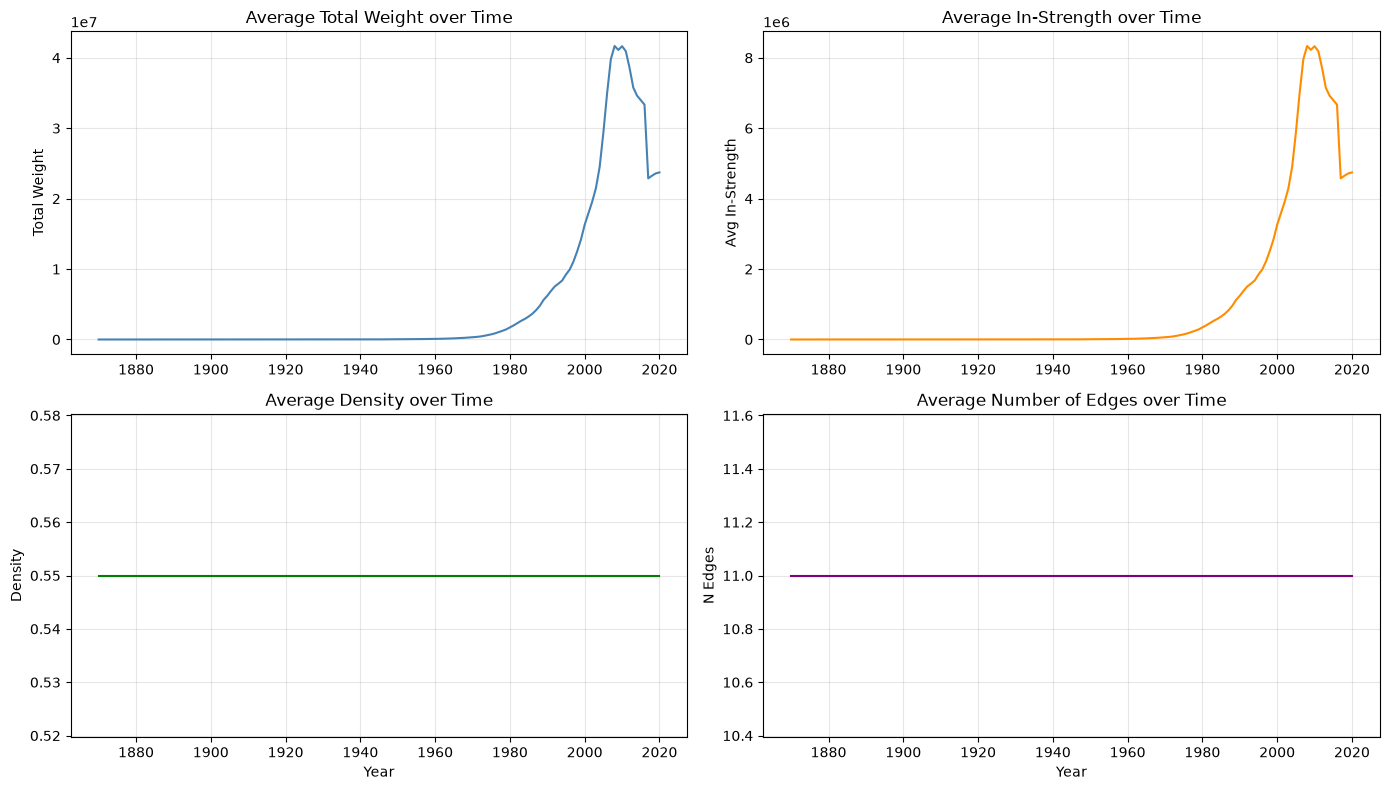

Saved figure → D:\univercity\omid_project\economics_project\outputs\phase4\figures\network_evolution_over_time.png

--- Phase 4 Final Status ---
Total networks : 2718
Countries      : 18
Year range     : 1870 – 2020

Cell 4 completed successfully.


In [4]:
# Phase 4 – Temporal Network Construction
# Cell 4: Network Evolution Summary + Final Save

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase4" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase4" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase4" / "figures"

metrics = pd.read_pickle(OUT_DATA / "network_structural_metrics.pkl")

print("=" * 60)
print("Phase 4 – Temporal Network Construction | Cell 4")
print("Network Evolution Summary")
print("=" * 60)

# Average metrics by year (across countries)
yearly = metrics.groupby("year").agg({
    "total_weight": "mean",
    "avg_in_strength": "mean",
    "density": "mean",
    "n_edges": "mean"
}).reset_index()

print("\n--- Yearly Average Metrics (sample) ---")
print(yearly.head(10).to_string(index=False))
print("...")
print(yearly.tail(5).to_string(index=False))

yearly.to_csv(OUT_TAB / "network_yearly_avg_metrics.csv", index=False)

# ---------------------- Simple evolution plot ----------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(yearly["year"], yearly["total_weight"], color="steelblue")
axes[0, 0].set_title("Average Total Weight over Time")
axes[0, 0].set_ylabel("Total Weight")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(yearly["year"], yearly["avg_in_strength"], color="darkorange")
axes[0, 1].set_title("Average In-Strength over Time")
axes[0, 1].set_ylabel("Avg In-Strength")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(yearly["year"], yearly["density"], color="green")
axes[1, 0].set_title("Average Density over Time")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_xlabel("Year")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(yearly["year"], yearly["n_edges"], color="purple")
axes[1, 1].set_title("Average Number of Edges over Time")
axes[1, 1].set_ylabel("N Edges")
axes[1, 1].set_xlabel("Year")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG / "network_evolution_over_time.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure → {OUT_FIG / 'network_evolution_over_time.png'}")

print("\n--- Phase 4 Final Status ---")
print(f"Total networks : {len(metrics)}")
print(f"Countries      : {metrics['country'].nunique()}")
print(f"Year range     : {metrics['year'].min()} – {metrics['year'].max()}")
print("\nCell 4 completed successfully.")